In [5]:

from tqdm import tqdm
import os
from tbparse import SummaryReader
import pandas as pd



# Overview over the first experiment

Train:
- 70% of participants as train
- 30% as test

different combination tested:
- Architecture: unet, unet++, deeplabv3, fpn, pspnet, segformer
- Encoder: resnet34, resnet50, efficientnet-b0, efficientnet-b1, efficientnet-b2, efficientnet-b3 
- Input normalization: None, min-max, z-score

In [6]:
from utils import read_runs
results_df = read_runs("runs", "Segmentationmodels_full_supervised_training")
results_df.head()

Summary file results/Segmentationmodels_full_supervised_training_summary.csv already exists. Loading it.


,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss
0,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,none,20.0,4.0,0.7,0.0001,0.013829,0.980201,0.961566,0.017297
1,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,minmax,20.0,4.0,0.7,0.0001,0.014083,0.980974,0.963021,0.016860
2,deeplabv3+,1.0,16.0,efficientnet-b0,1.0,0.5,0.001,0.0,zscore,20.0,4.0,0.7,0.0001,0.015089,0.979529,0.960246,0.017916
3,deeplabv3+,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,none,20.0,4.0,0.7,0.0001,0.014826,0.981209,0.963635,0.017127
4,deeplabv3+,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,minmax,20.0,4.0,0.7,0.0001,0.014141,0.980707,0.962818,0.017709


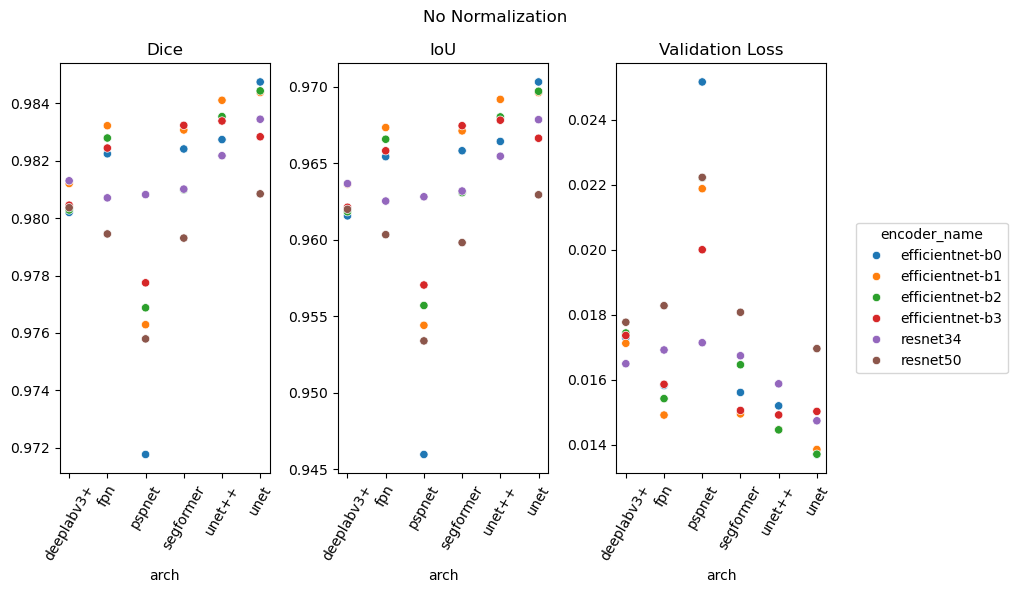

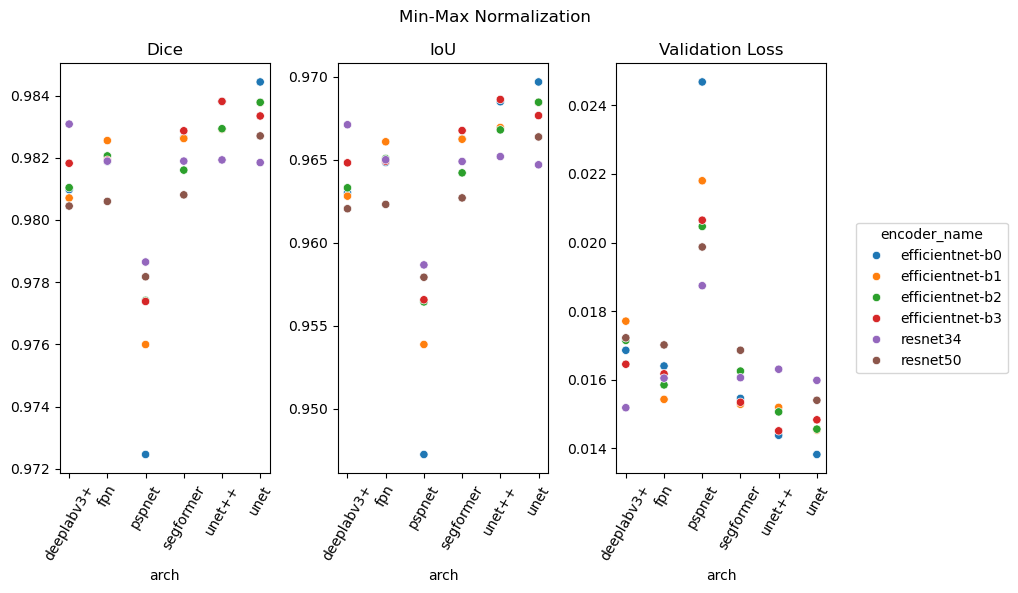

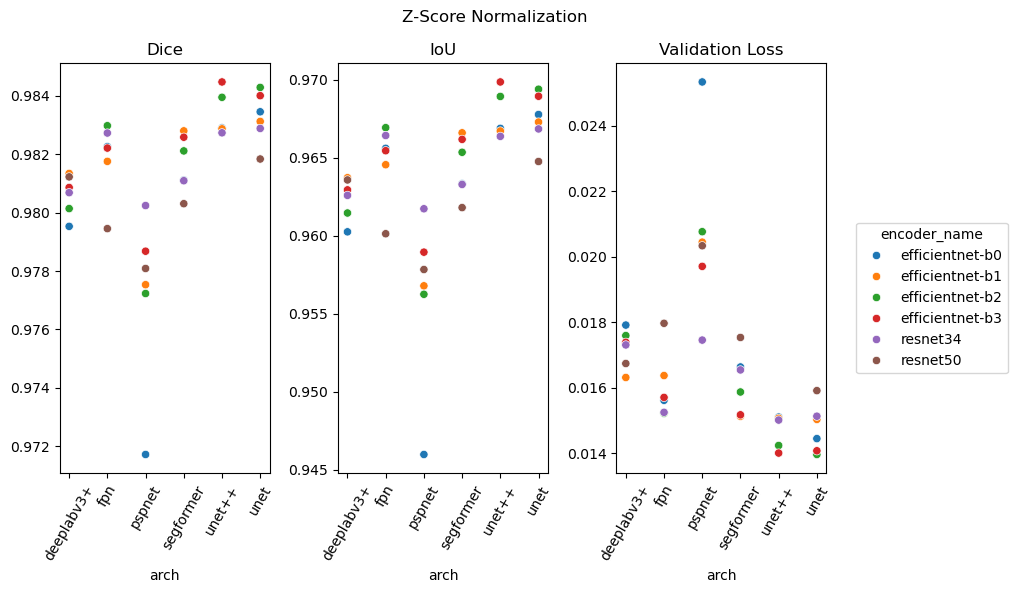

In [7]:
# plot scatter: x-axes architecture, y-axes val_dice, color by encoder_name
import matplotlib.pyplot as plt
import seaborn as sns

def plot_results(data, x, hue, title):
    fig, axs = plt.subplots(1, 3, figsize=(10, 6))

    sns.scatterplot(data=data, x=x, y="val_dice", hue=hue, ax=axs[0])
    axs[0].set_title("Dice")
    axs[0].set_ylabel("")
    sns.scatterplot(data=data, x=x, y="val_iou", hue=hue, ax=axs[1], legend=False)
    axs[1].set_title("IoU")
    axs[1].set_ylabel("")
    sns.scatterplot(data=data, x=x, y="val_loss", hue=hue, ax=axs[2], legend=False)
    axs[2].set_title("Validation Loss")
    axs[2].set_ylabel("")

    handles, labels = axs[0].get_legend_handles_labels()
    if axs[0].legend_ is not None:
        axs[0].legend_.remove()
    fig.legend(handles, labels, title=hue, loc="center right", bbox_to_anchor=(1.02, 0.5))

    for ax in axs:
        ax.tick_params(axis="x", labelrotation=60)

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

res_none_norm = results_df[results_df["normalize"] == "none"]
plot_results(res_none_norm, x="arch", hue="encoder_name", title="No Normalization")
res_minmax_norm = results_df[results_df["normalize"] == "minmax"]
plot_results(res_minmax_norm, x="arch", hue="encoder_name", title="Min-Max Normalization") 
res_zscore_norm = results_df[results_df["normalize"] == "zscore"]
plot_results(res_zscore_norm, x="arch", hue="encoder_name", title="Z-Score Normalization")

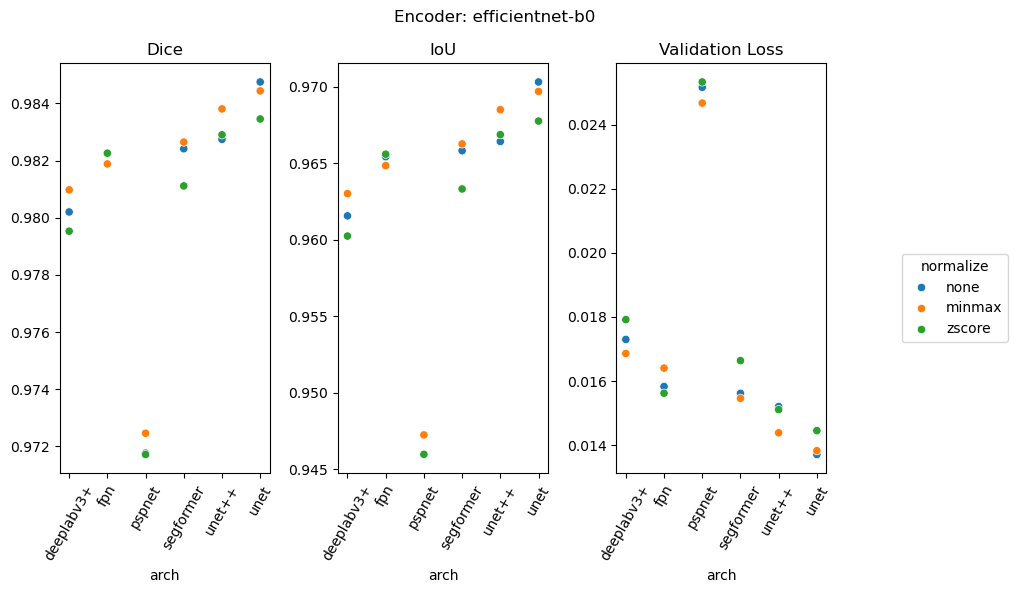

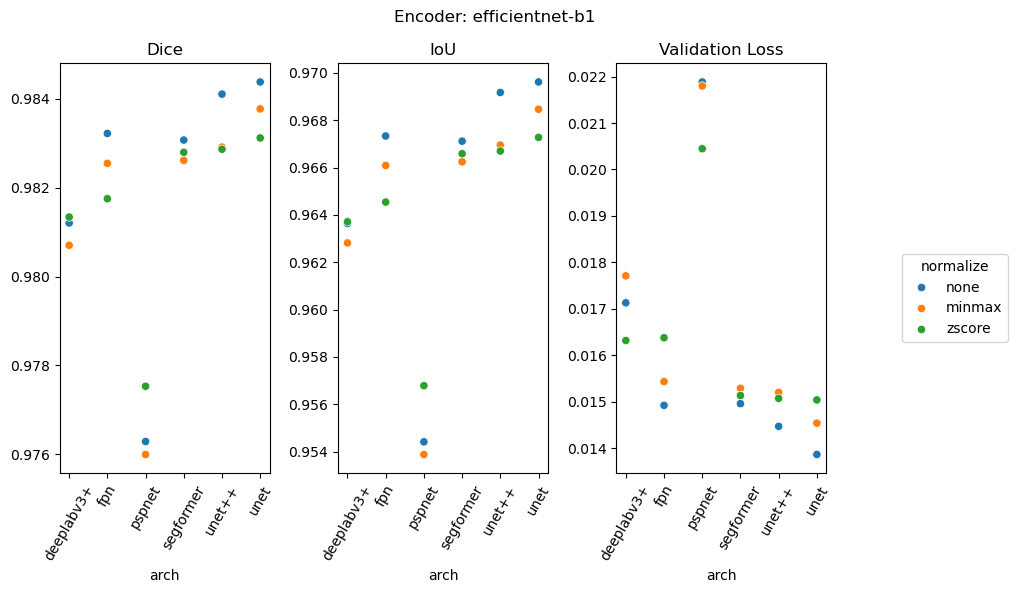

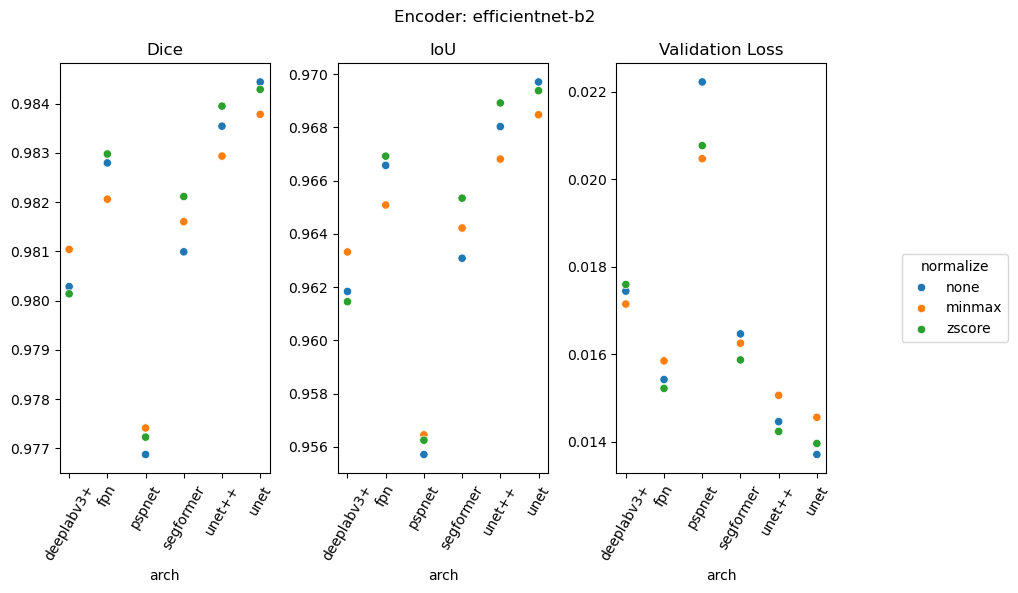

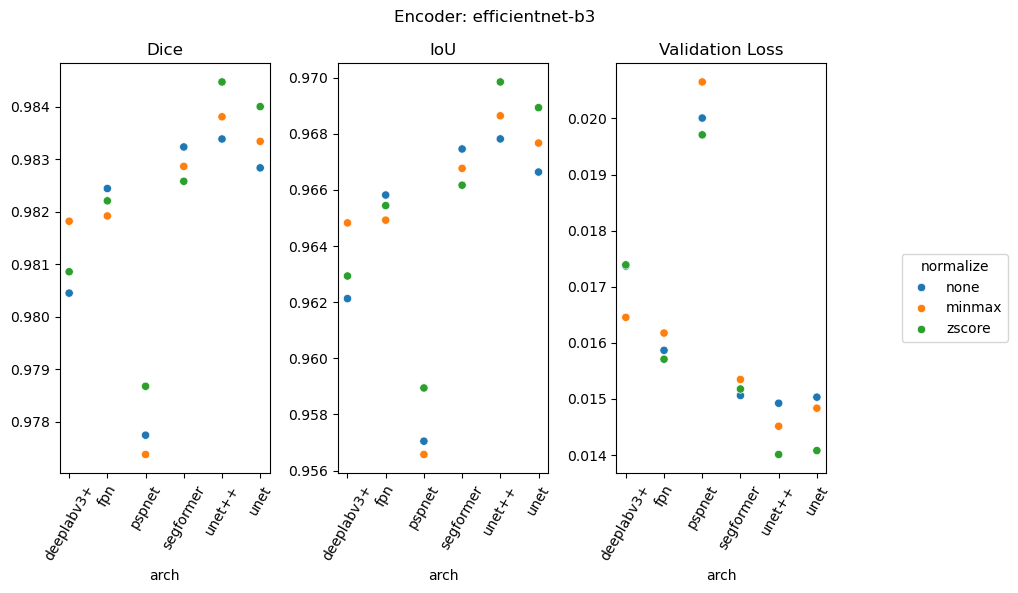

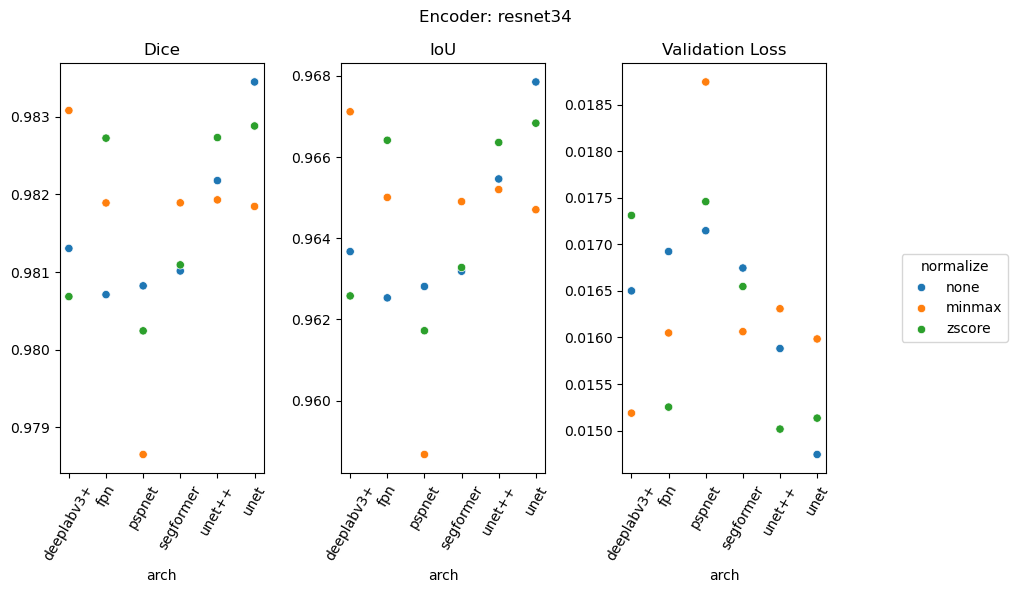

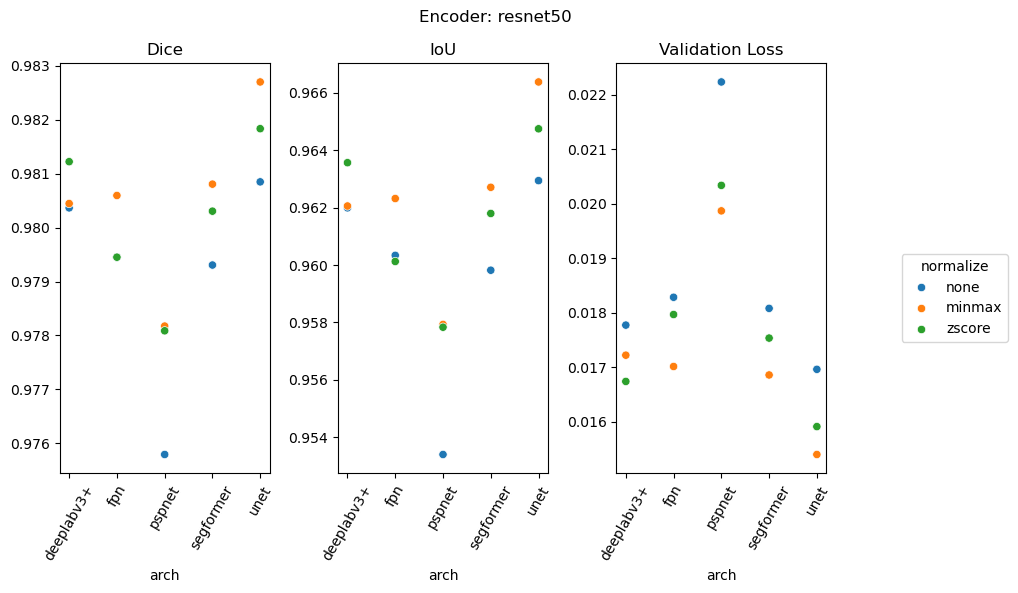

In [8]:
encoder = results_df["encoder_name"].unique()
for enc in encoder:
    res_enc = results_df[results_df["encoder_name"] == enc]
    plot_results(res_enc, x="arch", hue="normalize", title=f"Encoder: {enc}")

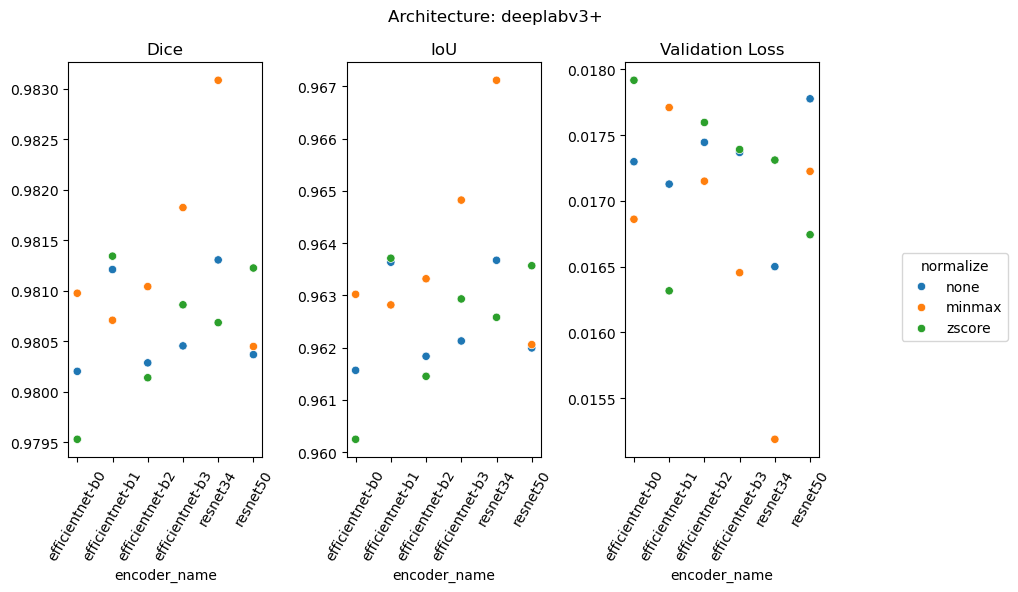

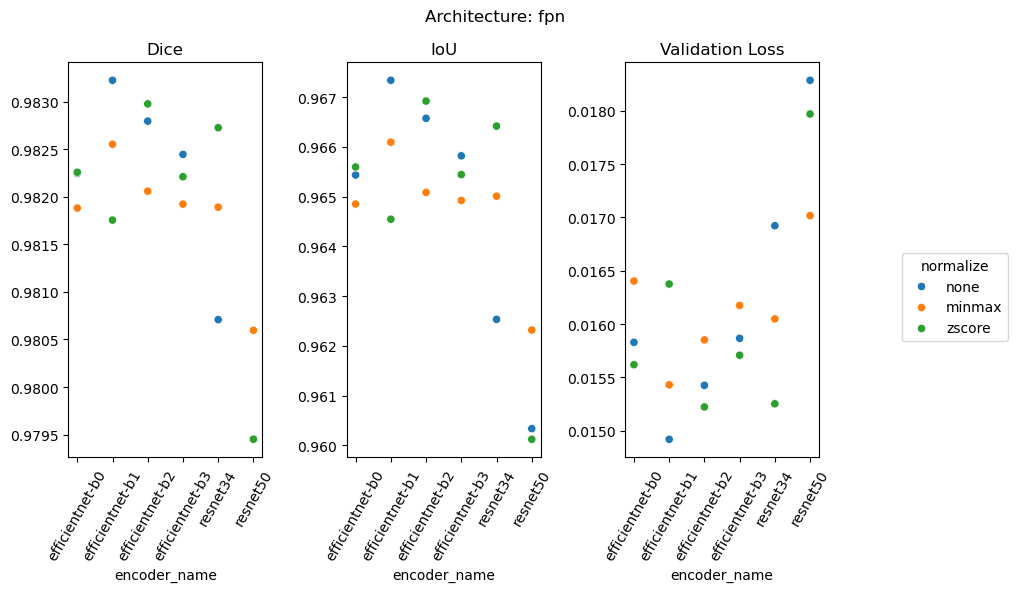

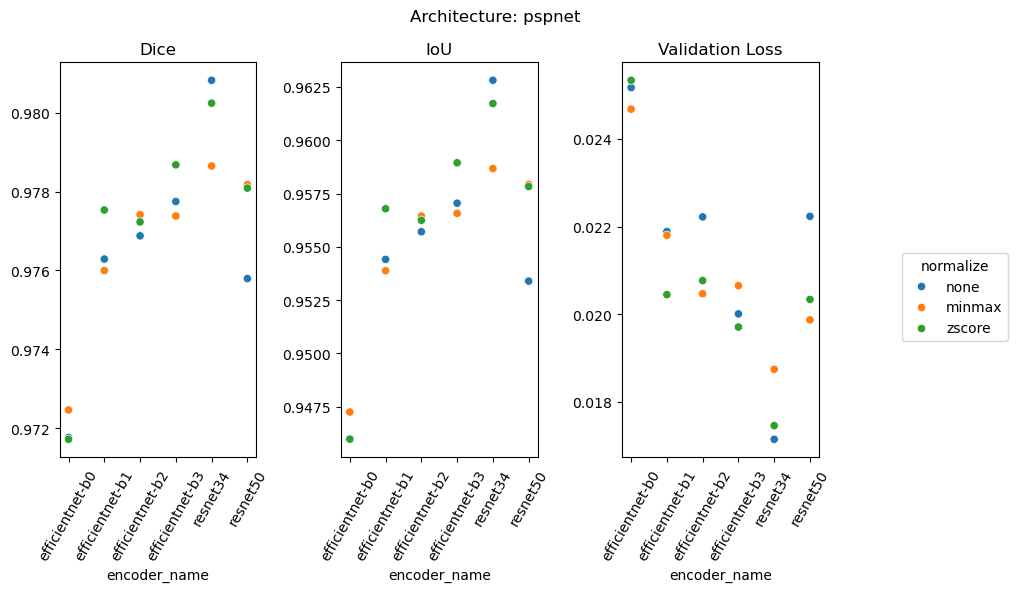

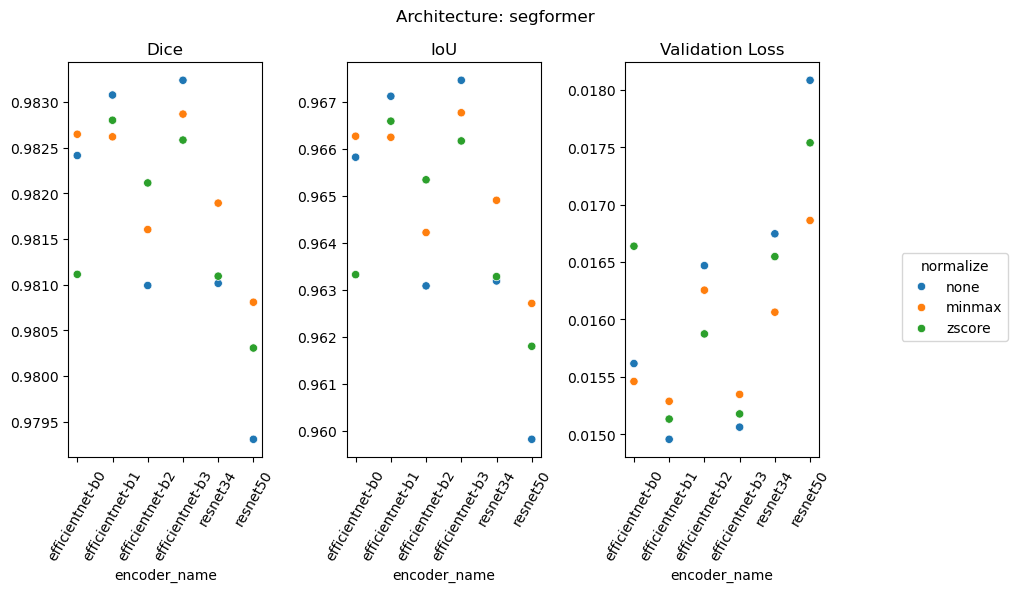

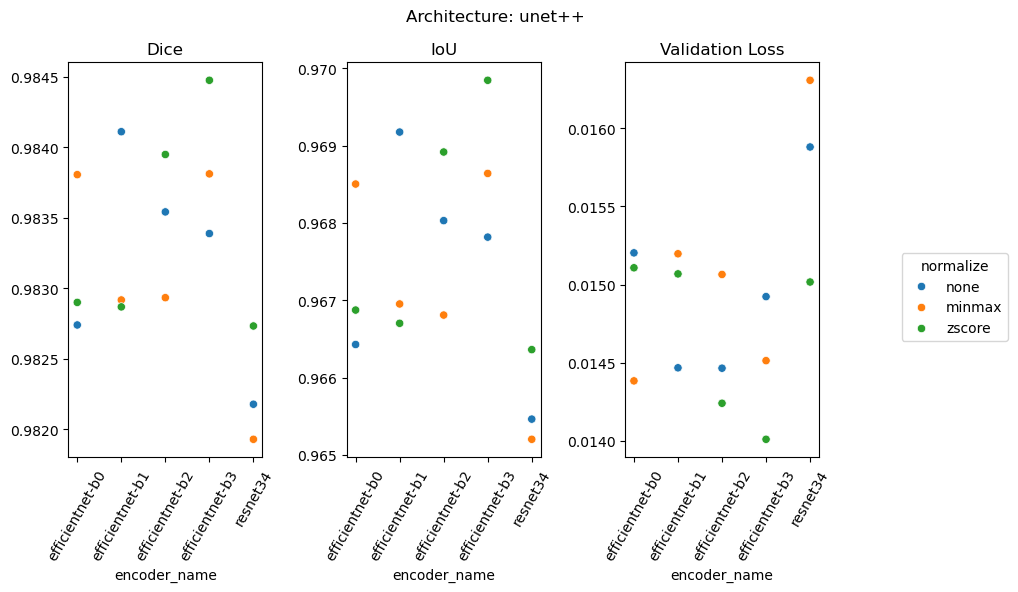

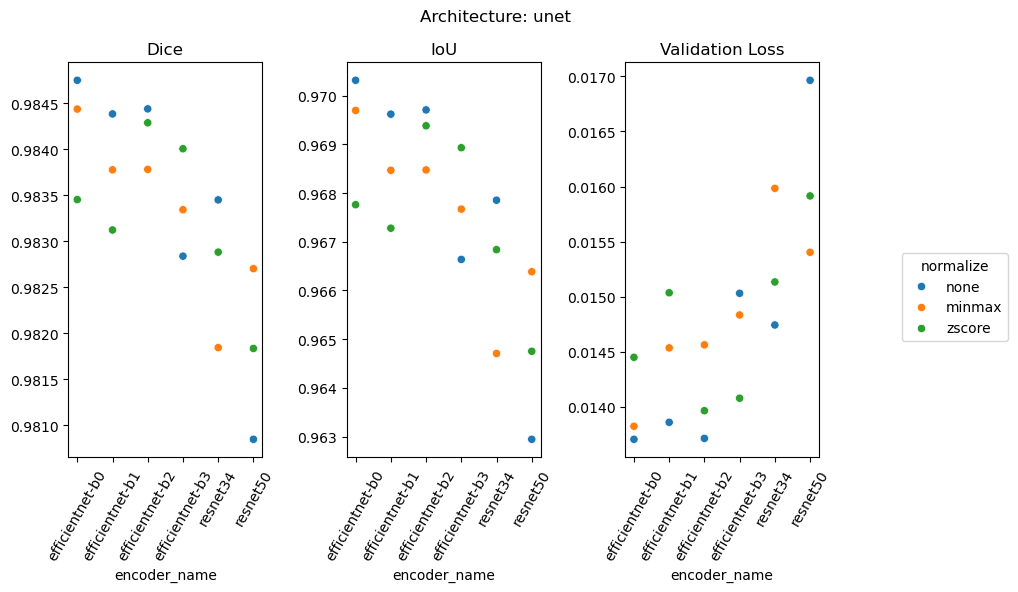

In [9]:
archs = results_df["arch"].unique()
for arch in archs:
    res_arch = results_df[results_df["arch"] == arch]
    plot_results(res_arch, x="encoder_name", hue="normalize", title=f"Architecture: {arch}")

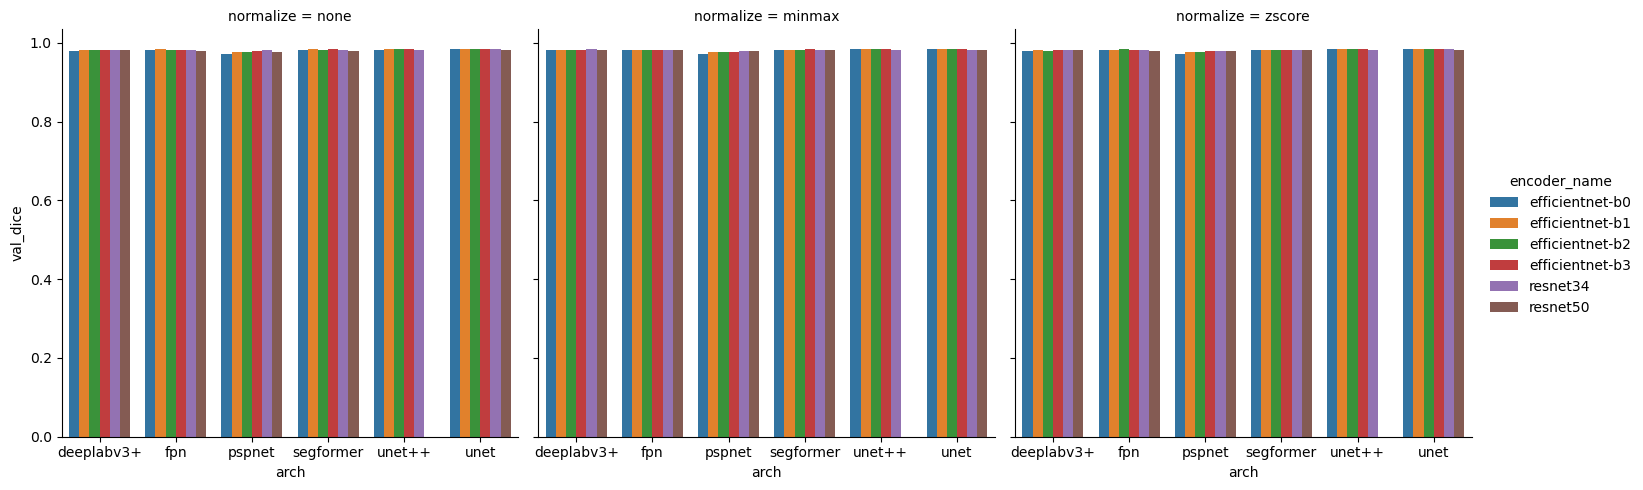

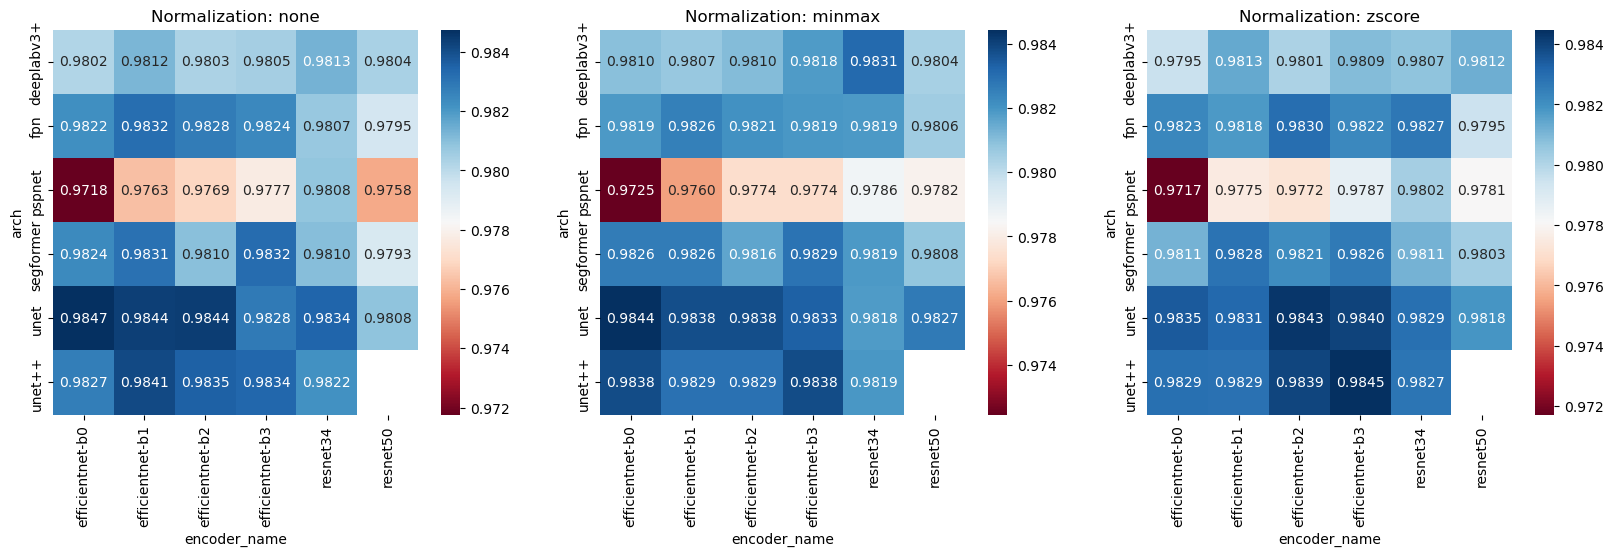

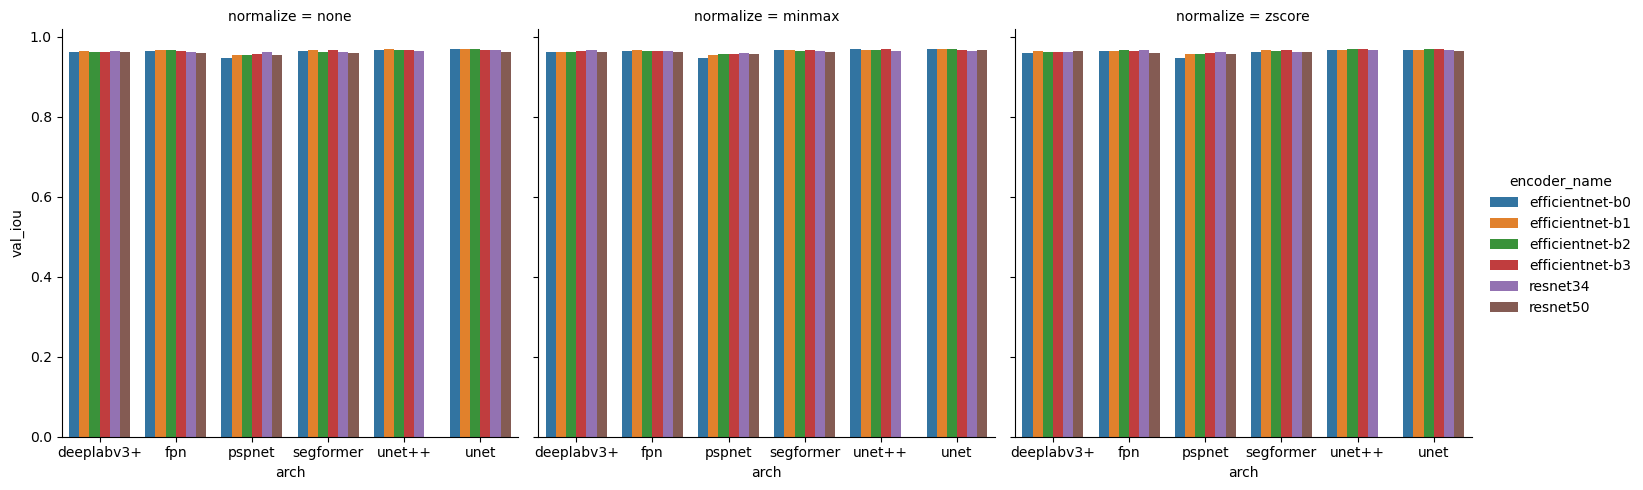

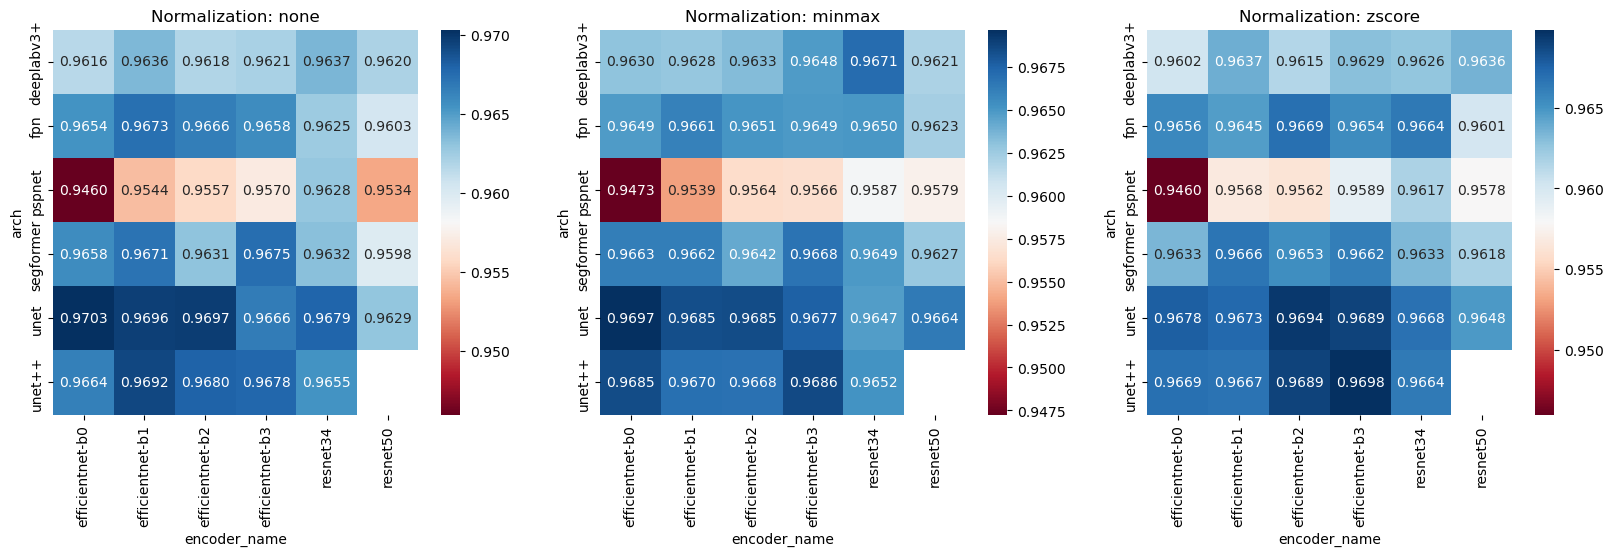

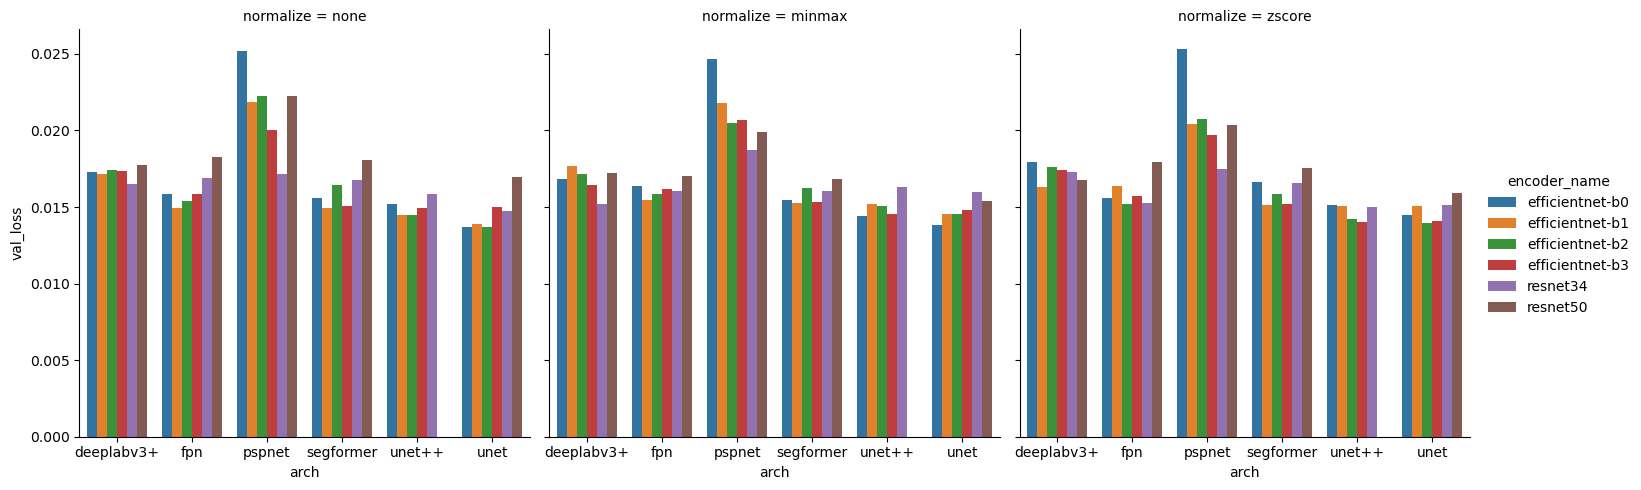

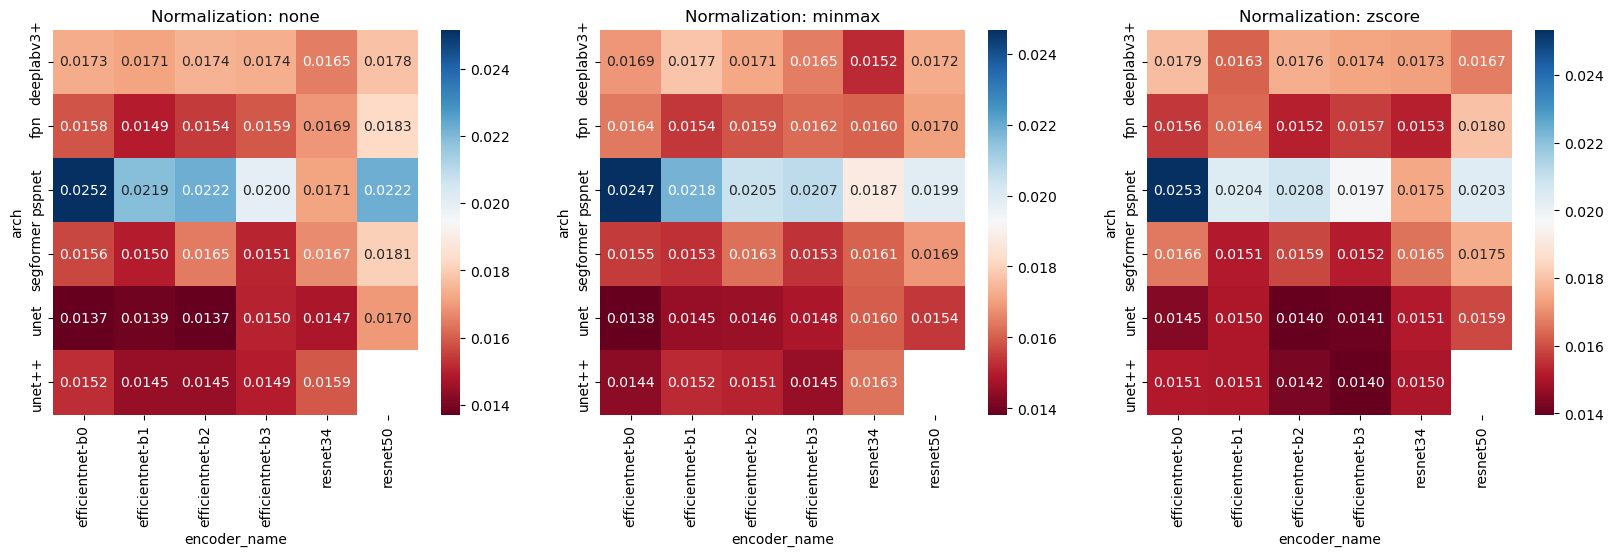

In [10]:
for metric in ["val_dice", "val_iou", "val_loss"]:
    sns.catplot(
        data = results_df,
        x = "arch",
        y = metric,
        hue = "encoder_name",
        col = "normalize",
        kind="bar"
    )
    plt.show()

    fig, axs = plt.subplots(1, 3, figsize=(20, 5))
    for i, norm in enumerate(results_df["normalize"].unique()):
        pivot = results_df[results_df["normalize"] == norm].pivot_table(index="arch", columns="encoder_name", values=metric)
        sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdBu",ax=axs[i])
        axs[i].set_title(f"Normalization: {norm}")

# Results second experiment

Encoder pretraining:
- self supervised
- other oct dataset without lables
- zscore normalization 

Arch training:
- 5% of the participants are training
- 95% are testing
- Compare pretrained vs from scratch


In [23]:
from utils import read_runs
results_df = read_runs("runs", "scratchVSpretrained")
results_df["pretrained"] = ~results_df["encoder_weights_path"].isna()
results_df.sort_values("val_dice",ascending=False).head()


Summary file results/scratchVSpretrained_summary.csv already exists. Loading it.


,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,num_freeze_encoder_epochs,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss,encoder_weights_path,pretrained
212,unet,1.0,16.0,vgg11_bn,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.05,0.0001,0.038677,0.949458,0.906485,0.045040,NaN,False
187,unet,1.0,16.0,efficientnet-b3,1.0,0.5,0.001,0.0,zscore,20.0,10.0,0.0,0.05,0.0001,0.036895,0.946830,0.902161,0.049844,trained_models/encoder_models/pretrained_effic...,True
135,segformer,1.0,16.0,efficientnet-b1,1.0,0.5,0.001,0.0,zscore,20.0,10.0,0.0,0.05,0.0001,0.036014,0.944459,0.898207,0.048805,trained_models/encoder_models/pretrained_effic...,True
216,unet,1.0,16.0,vgg13_bn,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.05,0.0001,0.038583,0.942435,0.898712,0.053302,NaN,False
208,unet,1.0,16.0,resnet34,1.0,0.5,0.001,0.0,zscore,20.0,0.0,0.0,0.05,0.0001,0.045082,0.941554,0.896913,0.055725,NaN,False


In [24]:
df_pivot = results_df.pivot_table(
    index=["arch", "encoder_name", "normalize"],
    values=["val_dice", "val_iou", "val_loss"],
    columns="pretrained"
).reset_index()
df_pivot["delta_dice"] = df_pivot[("val_dice", True)] - df_pivot[("val_dice", False)]
df_pivot["delta_iou"] = df_pivot[("val_iou", True)] - df_pivot[("val_iou", False)]
df_pivot["delta_loss"] = df_pivot[("val_loss", False)] - df_pivot[("val_loss", True)] # because lower loss is better, so we subtract pretrained from scratch to get a positive delta if pretrained is better 
df_pivot.head()

arch     encoder_name normalize      val_dice            \
pretrained                                                False      True   
0           deeplabv3+            dpn68    zscore  9.109428e-01  0.919199   
1           deeplabv3+  efficientnet-b0    zscore  4.403747e-12  0.881573   
2           deeplabv3+  efficientnet-b1    zscore  4.403747e-12  0.917448   
3           deeplabv3+  efficientnet-b2    zscore  4.403747e-12  0.923751   
4           deeplabv3+  efficientnet-b3    zscore  4.403747e-12  0.910041   

                 val_iou            val_loss           delta_dice delta_iou  \
pretrained         False      True     False      True                        
0           8.505639e-01  0.861124  0.078700  0.073944   0.008256  0.010560   
1           4.403747e-12  0.804741  0.635246  0.100794   0.881573  0.804741   
2           4.403747e-12  0.856323  0.647531  0.073978   0.917448  0.856323   
3           4.403747e-12  0.865500  0.595529  0.066902   0.923751  0.865500   
4           4.403747e-12  0.844908  0.644059  0.080247   0.910041  0.844908   

           delta_loss  
pretrained             
0            0.004756  
1            0.534452  
2            0.573553  
3            0.528626  
4            0.563812

In [25]:
df_pivot

arch     encoder_name normalize      val_dice            \
pretrained                                                False      True   
0           deeplabv3+            dpn68    zscore  9.109428e-01  0.919199   
1           deeplabv3+  efficientnet-b0    zscore  4.403747e-12  0.881573   
2           deeplabv3+  efficientnet-b1    zscore  4.403747e-12  0.917448   
3           deeplabv3+  efficientnet-b2    zscore  4.403747e-12  0.923751   
4           deeplabv3+  efficientnet-b3    zscore  4.403747e-12  0.910041   
..                 ...              ...       ...           ...       ...   
107               unet            vgg13    zscore  9.145974e-01  0.935593   
108               unet         vgg13_bn    zscore  9.424350e-01  0.935288   
109               unet            vgg16    zscore  8.985370e-01  0.940802   
110               unet         vgg16_bn    zscore  9.408932e-01  0.940751   
111               unet         vgg19_bn    zscore  9.412264e-01  0.919413   

                 val_iou            val_loss           delta_dice delta_iou  \
pretrained         False      True     False      True                        
0           8.505639e-01  0.861124  0.078700  0.073944   0.008256  0.010560   
1           4.403747e-12  0.804741  0.635246  0.100794   0.881573  0.804741   
2           4.403747e-12  0.856323  0.647531  0.073978   0.917448  0.856323   
3           4.403747e-12  0.865500  0.595529  0.066902   0.923751  0.865500   
4           4.403747e-12  0.844908  0.644059  0.080247   0.910041  0.844908   
..                   ...       ...       ...       ...        ...       ...   
107         8.560241e-01  0.884959  0.075203  0.057376   0.020996  0.028935   
108         8.987123e-01  0.886405  0.053302  0.060624  -0.007147 -0.012308   
109         8.242756e-01  0.892085  0.087729  0.055174   0.042265  0.067810   
110         8.936357e-01  0.893291  0.055986  0.055566  -0.000143 -0.000345   
111         8.954377e-01  0.856426  0.052168  0.071019  -0.021813 -0.039012   

           delta_loss  
pretrained             
0            0.004756  
1            0.534452  
2            0.573553  
3            0.528626  
4            0.563812  
..                ...  
107          0.017827  
108         -0.007322  
109          0.032555  
110          0.000420  
111         -0.018850  

[112 rows x 12 columns]

In [26]:
", ".join(df_pivot.encoder_name.unique())

'dpn68, efficientnet-b0, efficientnet-b1, efficientnet-b2, efficientnet-b3, efficientnet-b4, mit_b0, mit_b1, mobilenet_v2, mobileone_s0, mobileone_s1, mobileone_s2, mobileone_s3, mobileone_s4, resnet18, resnet34, densenet121, vgg11, vgg11_bn, vgg13, vgg13_bn, vgg16, vgg16_bn, vgg19_bn'

[]

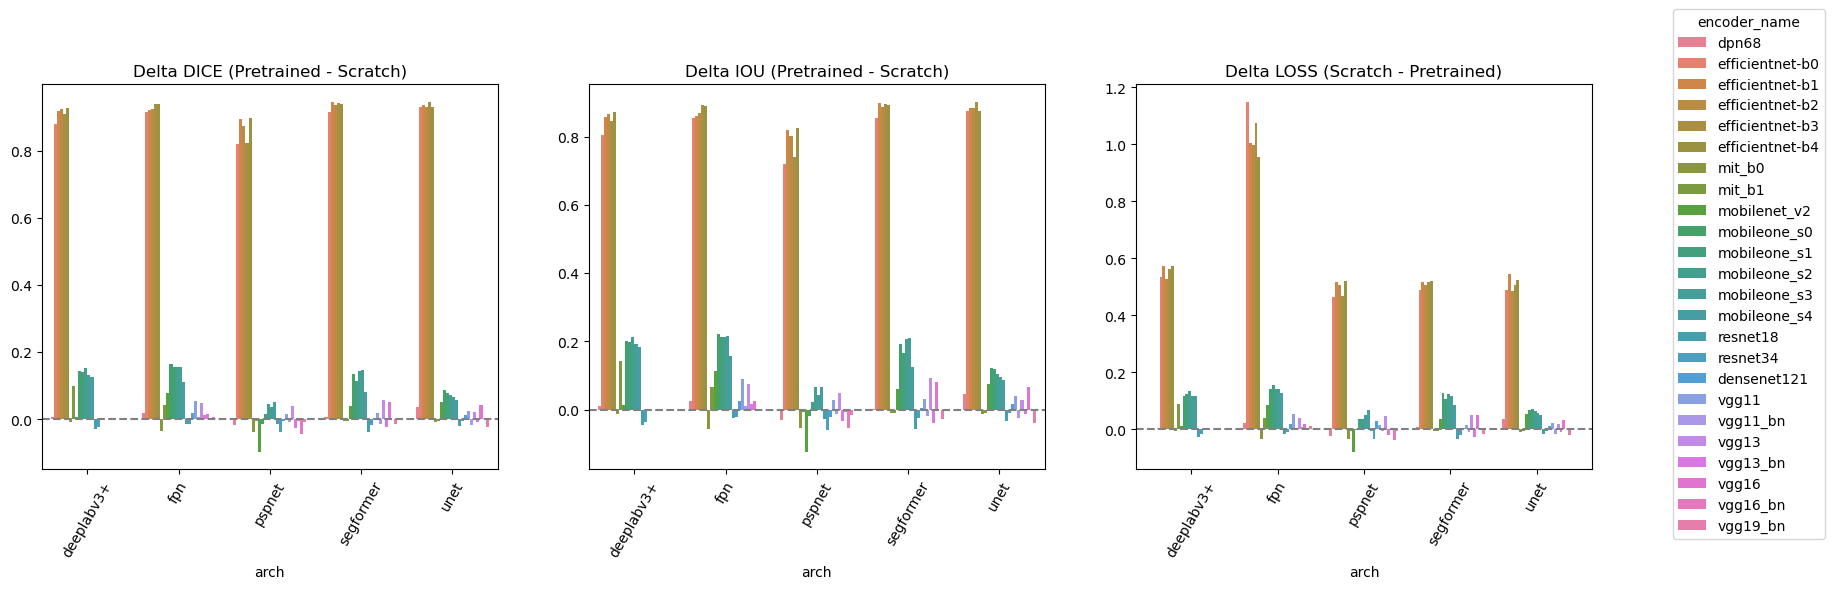

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i, metric in enumerate(["delta_dice", "delta_iou", "delta_loss"]):
    sns.barplot(data=df_pivot, x="arch", y=metric, hue="encoder_name", ax=axs[i], legend=i==0)
    axs[i].set_title(f"Delta {metric.split('_')[1].upper()} ({"Pretrained - Scratch" if metric != "delta_loss" else "Scratch - Pretrained"})")
    axs[i].set_ylabel("")
    axs[i].tick_params(axis="x", labelrotation=60)
    axs[i].axhline(0, color="gray", linestyle="--")

handles, labels = axs[0].get_legend_handles_labels()
if axs[0].legend_ is not None:
    axs[0].legend_.remove()
fig.legend(handles, labels, title="encoder_name", loc="center right", bbox_to_anchor=(1.02, 0.5))
plt.plot()

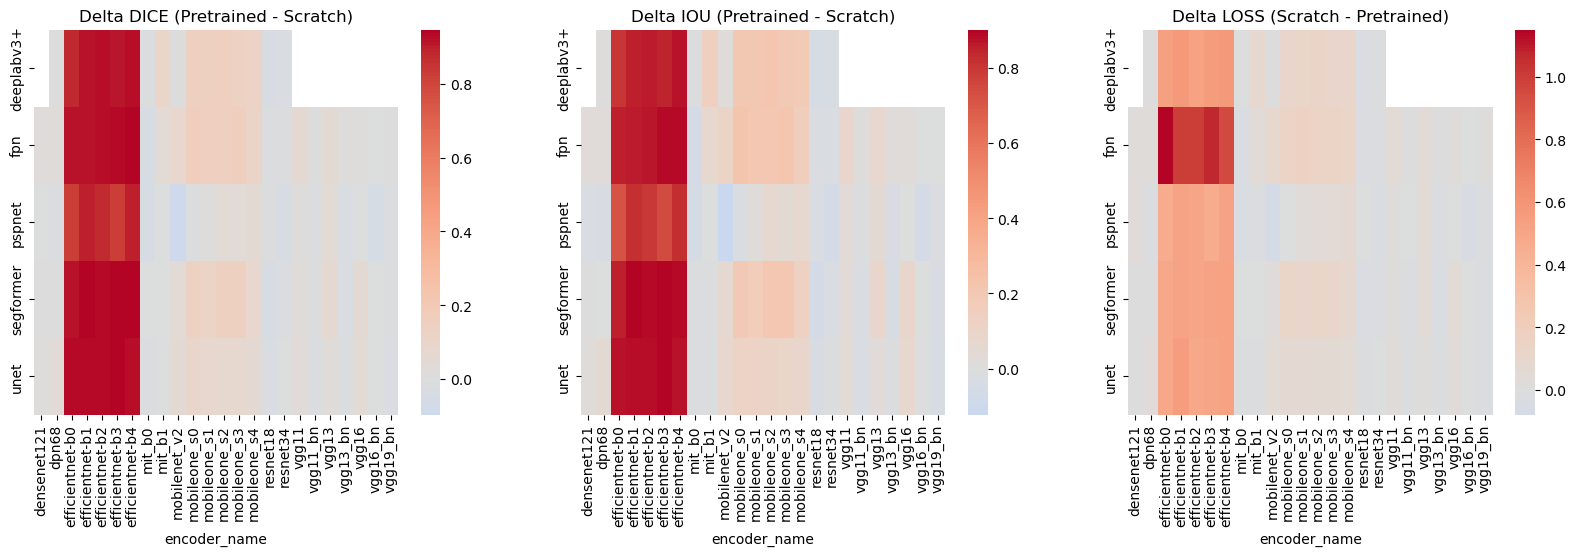

In [28]:
df_pivot.columns = [
    "_".join([str(c) for c in col if c != ""]).strip()
    if isinstance(col, tuple)
    else col
    for col in df_pivot.columns
]

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i, metric in enumerate(["delta_dice", "delta_iou", "delta_loss"]):
    pivot = df_pivot.pivot_table(index="arch", columns="encoder_name", values=metric)
    sns.heatmap(pivot, annot=False, fmt=".1f", cmap="coolwarm", ax=axs[i], center=0)
    axs[i].set_title(f"Delta {metric.split('_')[1].upper()} ({"Pretrained - Scratch" if metric != "delta_loss" else "Scratch - Pretrained"})")
    axs[i].set_ylabel("")
    axs[i].tick_params(axis="x", labelrotation=90)

plt.show()

In [29]:
axs

array([<Axes: title={'center': 'Delta DICE (Pretrained - Scratch)'}, xlabel='encoder_name'>,
       <Axes: title={'center': 'Delta IOU (Pretrained - Scratch)'}, xlabel='encoder_name'>,
       <Axes: title={'center': 'Delta LOSS (Scratch - Pretrained)'}, xlabel='encoder_name'>],
      dtype=object)

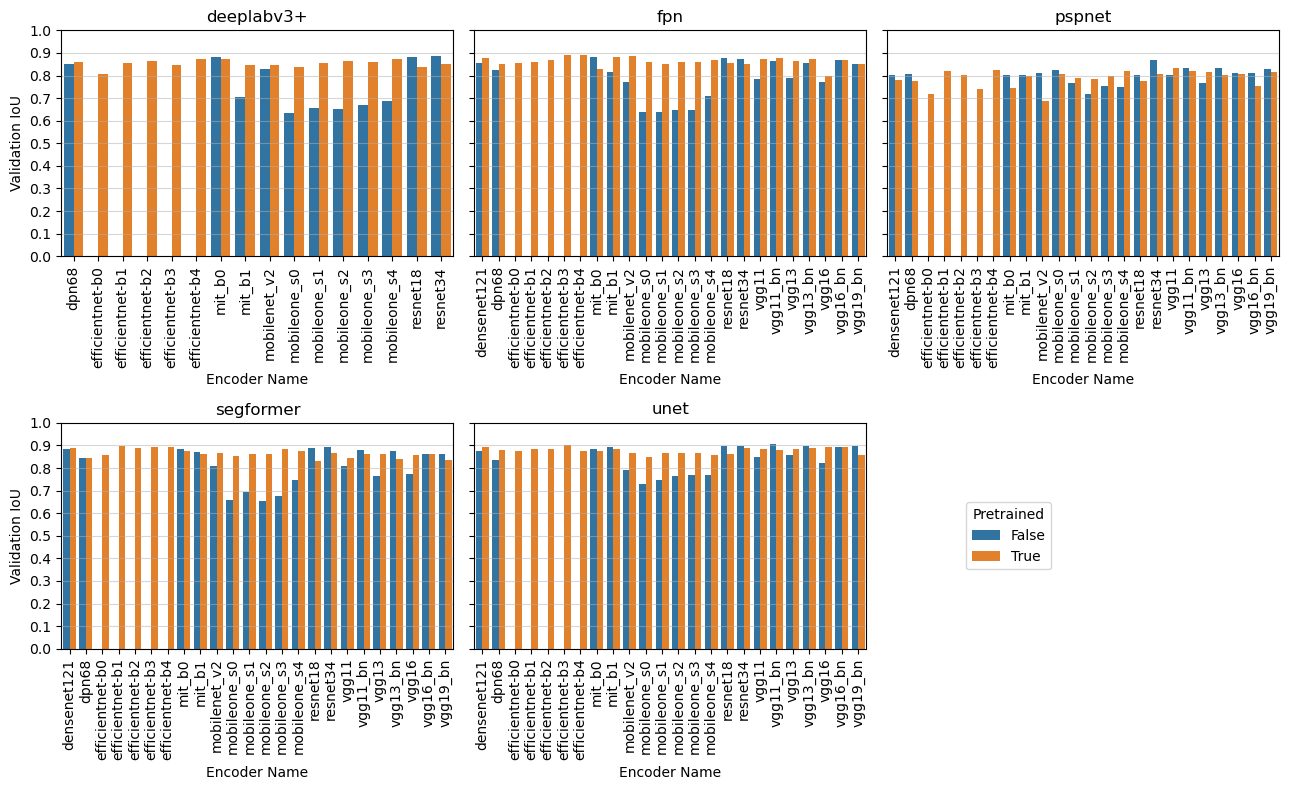

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation

archs = results_df["arch"].unique()

n = len(archs)
# fig, axs = plt.subplots(n//2 + n%2, 2, figsize=(10, 5*n//2 + n%2), sharey=True)
fig, axs = plt.subplots(2, n//2 + n%2, figsize=(5*n//2 + n%2, 8), sharey=True)
axs = axs.flatten()
legend_target_idx = n - 1 if n > 1 else 0
legend_x_offset_px = 100

# architecture = "segformer"
for i, architecture in enumerate(archs):

    results_arch = results_df[results_df["arch"] == architecture]
    results_arch.sort_values("val_dice", ascending=False)


    sns.barplot(data=results_arch, x="encoder_name", y="val_iou", hue="pretrained", ax=axs[i])
    axs[i].set_title(f"{architecture}")
    axs[i].set_xlabel("Encoder Name")
    axs[i].set_ylabel("Validation IoU")
    axs[i].set_ylim(0, 1)
    axs[i].set_yticks([i / 10 for i in range(11)])
    axs[i].tick_params(axis="x", rotation=90)
    axs[i].grid(axis="y", alpha=0.5)

    # Keep a single shared legend; position it with a fixed pixel offset.
    if axs[i].legend_ is not None:
        if i == legend_target_idx:
            px_offset = ScaledTranslation(legend_x_offset_px / fig.dpi, 0, fig.dpi_scale_trans)
            legend = axs[i].legend(
                title="Pretrained",
                loc="center left",
                bbox_to_anchor=(1.0, 0.5),
                bbox_transform=axs[i].transAxes + px_offset,
                borderaxespad=0,
            )
            # Prevent tight_layout from resizing subplots because of the legend.
            legend.set_in_layout(False)
        else:
            axs[i].legend_.remove()
if i < len(axs) - 1:
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")
plt.tight_layout()
plt.show()


# Third experiment

Idea:
- pretrain encoder (unsupervised) on 65% participants
- train full arch on 5% participants
- test on last 30%

Comparison:
- pretrained encoder vs from scratch

In [44]:
results_df = read_runs("runs", "scratchVSpretrainedOIMHS")
results_df["pretrained"] = ~results_df["encoder_weights_path"].isna()
results_df.sort_values("val_dice",ascending=False).head()

Summary file results/scratchVSpretrainedOIMHS_summary.csv already exists. Loading it.


,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,...,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss,encoder_weights_path,encoder_weight_path,pretrained
218,unet,1.0,16.0,resnet152,1.0,0.5,0.001,0.0,zscore,20.0,...,4.0,0.7,0.0001,0.023943,0.946840,0.903893,0.059890,NaN,NaN,False
143,segformer,1.0,16.0,mit_b1,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.027807,0.946581,0.903179,0.050457,NaN,NaN,False
241,unet,1.0,16.0,vgg16_bn,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.022393,0.946224,0.904111,0.058544,trained_models\encoder_models\pretrained_vgg16...,NaN,True
243,unet,1.0,16.0,vgg19_bn,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.024264,0.943459,0.899137,0.061502,trained_models\encoder_models\pretrained_vgg19...,NaN,True
159,segformer,1.0,16.0,resnet34,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.029153,0.943147,0.896259,0.055280,NaN,NaN,False


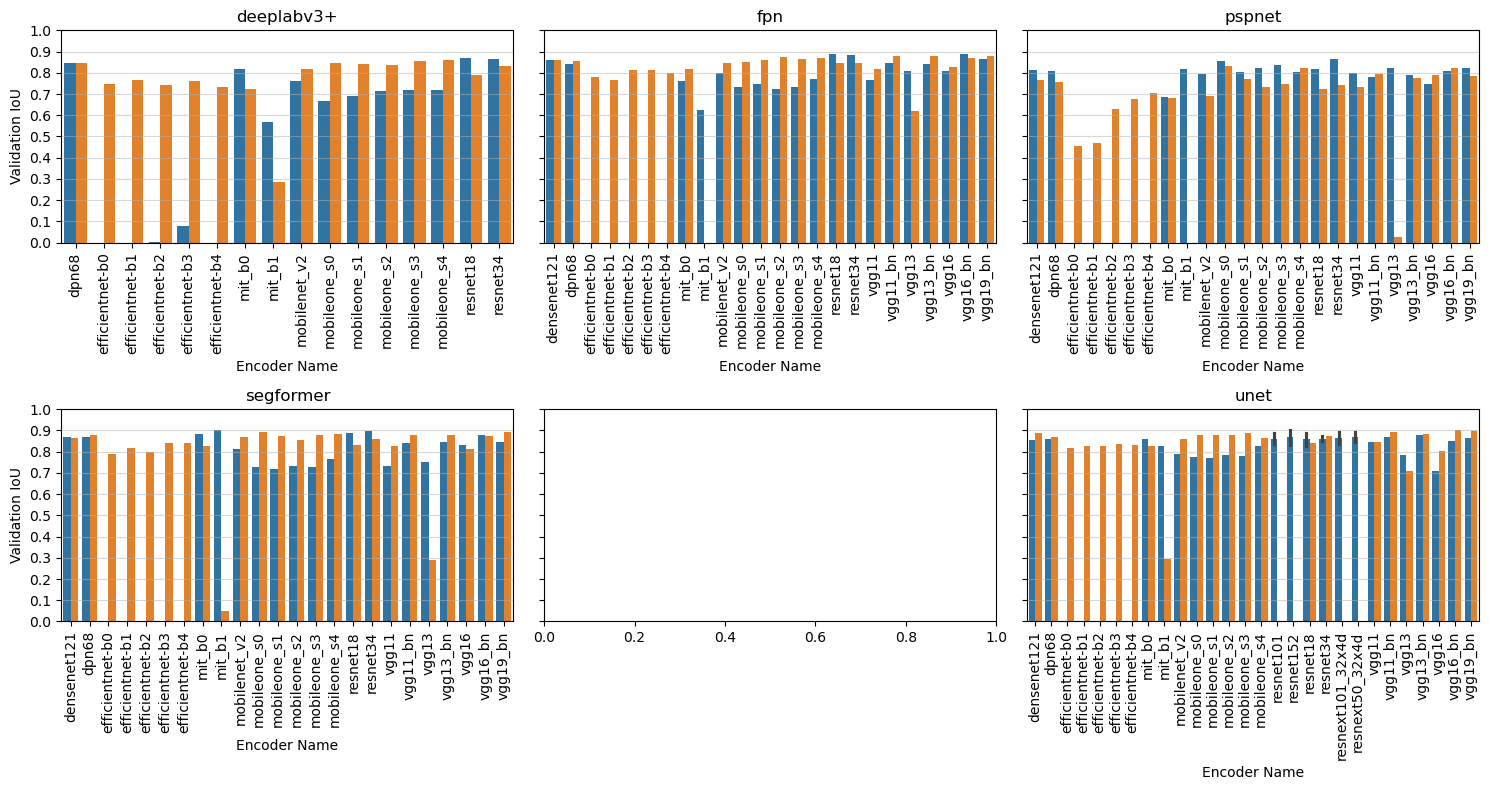

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.transforms import ScaledTranslation

archs = results_df["arch"].unique()

n = len(archs)
# fig, axs = plt.subplots(n//2 + n%2, 2, figsize=(10, 5*n//2 + n%2), sharey=True)
fig, axs = plt.subplots(2, n//2 + n%2, figsize=(5*n//2 + n%2, 8), sharey=True)
axs = axs.flatten()
legend_target_idx = 1 if n > 1 else 0
legend_x_offset_px = 100

# architecture = "segformer"
for i, architecture in enumerate(archs):
    if architecture == "unet++":
        continue

    results_arch = results_df[results_df["arch"] == architecture]
    results_arch.sort_values("val_dice", ascending=False)


    sns.barplot(data=results_arch, x="encoder_name", y="val_iou", hue="pretrained", ax=axs[i])
    axs[i].set_title(f"{architecture}")
    axs[i].set_xlabel("Encoder Name")
    axs[i].set_ylabel("Validation IoU")
    axs[i].set_ylim(0, 1)
    axs[i].set_yticks([i / 10 for i in range(11)])
    axs[i].tick_params(axis="x", rotation=90)
    axs[i].grid(axis="y", alpha=0.5)

    # Keep a single shared legend; position it with a fixed pixel offset.
    if axs[i].legend_ is not None:
        if i == legend_target_idx:
            px_offset = ScaledTranslation(legend_x_offset_px / fig.dpi, 0, fig.dpi_scale_trans)
            legend = axs[i].legend(
                title="Pretrained",
                loc="center left",
                bbox_to_anchor=(1.0, 0.5),
                bbox_transform=axs[i].transAxes + px_offset,
                borderaxespad=0,
            )
            # Prevent tight_layout from resizing subplots because of the legend.
            legend.set_in_layout(False)
        else:
            axs[i].legend_.remove()
if i < len(axs) - 1:
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")
plt.tight_layout()
plt.show()

In [46]:
df_pivot = results_df.pivot_table(
    index=["arch", "encoder_name", "normalize"],
    values=["val_dice", "val_iou", "val_loss"],
    columns="pretrained"
).reset_index()
df_pivot["delta_dice"] = df_pivot[("val_dice", True)] - df_pivot[("val_dice", False)]
df_pivot["delta_iou"] = df_pivot[("val_iou", True)] - df_pivot[("val_iou", False)]
df_pivot["delta_loss"] = df_pivot[("val_loss", False)] - df_pivot[("val_loss", True)] # because lower loss is better, so we subtract pretrained from scratch to get a positive delta if pretrained is better 
df_pivot.head()

arch     encoder_name normalize      val_dice            \
pretrained                                                False      True   
0           deeplabv3+            dpn68    zscore  9.114909e-01  0.907705   
1           deeplabv3+  efficientnet-b0    zscore  4.184596e-12  0.842952   
2           deeplabv3+  efficientnet-b1    zscore  4.184596e-12  0.856058   
3           deeplabv3+  efficientnet-b2    zscore  5.655574e-03  0.834014   
4           deeplabv3+  efficientnet-b3    zscore  1.350345e-01  0.845365   

                 val_iou            val_loss           delta_dice delta_iou  \
pretrained         False      True     False      True                        
0           8.456758e-01  0.845153  0.089844  0.091584  -0.003786 -0.000523   
1           4.184596e-12  0.746403  0.617023  0.144012   0.842952  0.746403   
2           4.184596e-12  0.766815  0.609271  0.132324   0.856058  0.766815   
3           2.858065e-03  0.740385  0.594544  0.153571   0.828358  0.737527   
4           7.790073e-02  0.759563  0.599932  0.148583   0.710330  0.681663   

           delta_loss  
pretrained             
0           -0.001739  
1            0.473010  
2            0.476947  
3            0.440974  
4            0.451349

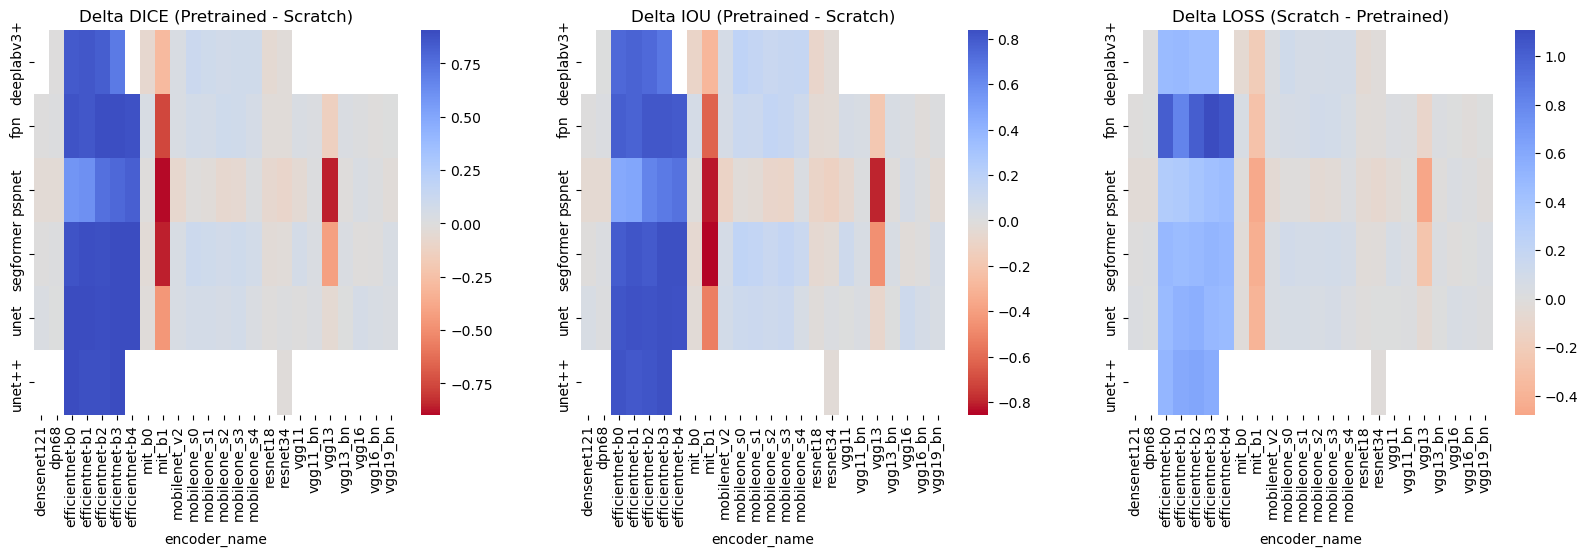

In [47]:
df_pivot.columns = [
    "_".join([str(c) for c in col if c != ""]).strip()
    if isinstance(col, tuple)
    else col
    for col in df_pivot.columns
]

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
for i, metric in enumerate(["delta_dice", "delta_iou", "delta_loss"]):
    pivot = df_pivot.pivot_table(index="arch", columns="encoder_name", values=metric)
    sns.heatmap(pivot, annot=False, fmt=".1f", cmap="coolwarm_r", ax=axs[i], center=0)
    axs[i].set_title(f"Delta {metric.split('_')[1].upper()} ({"Pretrained - Scratch" if metric != "delta_loss" else "Scratch - Pretrained"})")
    axs[i].set_ylabel("")
    axs[i].tick_params(axis="x", labelrotation=90)

plt.show()

In [48]:
# results_df.groupby(["arch", "pretrained"]).agg({"val_dice": ["max"]})
best_by_arch_pretrained = (
    results_df.loc[results_df.groupby(["arch", "pretrained"])["val_iou"].idxmax()]
    .sort_values(["arch", "pretrained"])
    .reset_index(drop=True)
)

best_by_arch_pretrained

,arch,augment,batch_size,encoder_name,gpu,hflip_p,lr,max_rotate_deg,normalize,num_epochs,...,num_workers,train_portion,weight_decay,train_loss_at_best_val,val_dice,val_iou,val_loss,encoder_weights_path,encoder_weight_path,pretrained
0,deeplabv3+,1.0,16.0,resnet18,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.019345,0.925399,0.871062,0.072827,NaN,NaN,False
1,deeplabv3+,1.0,16.0,mobileone_s4,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.019080,0.916574,0.859850,0.085636,trained_models\encoder_models\pretrained_mobil...,NaN,True
2,fpn,1.0,16.0,vgg16_bn,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.027545,0.938396,0.889087,0.062689,NaN,NaN,False
3,fpn,1.0,16.0,vgg11_bn,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.023309,0.931982,0.880531,0.069850,trained_models\encoder_models\pretrained_vgg11...,NaN,True
4,pspnet,1.0,16.0,resnet34,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.021576,0.923177,0.866214,0.075203,NaN,NaN,False
5,pspnet,1.0,16.0,mobileone_s0,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.026859,0.904289,0.833555,0.092277,trained_models\encoder_models\pretrained_mobil...,NaN,True
6,segformer,1.0,16.0,mit_b1,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.027807,0.946581,0.903179,0.050457,NaN,NaN,False
7,segformer,1.0,16.0,vgg19_bn,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.023523,0.940748,0.893022,0.055472,trained_models\encoder_models\pretrained_vgg19...,NaN,True
8,unet,1.0,16.0,resnet152,1.0,0.5,0.001,0.0,zscore,20.0,...,4.0,0.7,0.0001,0.023943,0.946840,0.903893,0.059890,NaN,NaN,False
9,unet,1.0,16.0,vgg16_bn,1.0,0.5,0.001,0.0,zscore,20.0,...,0.0,0.7,0.0001,0.022393,0.946224,0.904111,0.058544,trained_models\encoder_models\pretrained_vgg16...,NaN,True
